# Module 2: Discrete Time Random Walk

A random walk is a simple stochastic process that moves step by step.

In this module, we use a random walk to connect three ideas: a single sample path, the distribution of a final position, and a hitting problem with two boundaries.

At each step, the position either increases by 1 or decreases by 1. Although the rule is simple, repeated simulations can show many different possible paths.

## Libraries

Run the cell below to import the libraries used in this module.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

In [26]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Example 1: One random walk path

A particle starts at position $0$ on a line. At each step, it moves one unit to the right with probability $p$, and one unit to the left with probability $1-p$. We write

$$
Z_k =
\begin{cases}
1, & \text{if the particle moves right},\\
-1, & \text{if the particle moves left}.
\end{cases}
$$

The position after $n$ steps is

$$
X_n = Z_1 + Z_2 + \cdots + Z_n, \qquad X_0 = 0.
$$

This is a discrete time process because the position is updated only at the integer times $0,1,2,\ldots$.

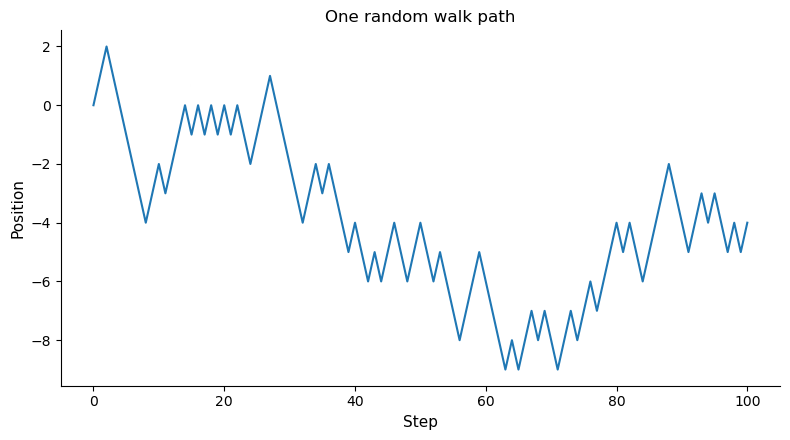

In [27]:
# Number of steps
n_steps = 100

# Probability of moving to the right
p = 0.5

# Create a random generator
rng = np.random.default_rng()

# Simulate the steps: +1 for right, -1 for left
steps = rng.choice([1, -1], size=n_steps, p=[p, 1 - p])

# Compute the position after each step
X = np.cumsum(steps)

# Add the starting position X_0 = 0
X = np.concatenate(([0], X))

# Plot one random walk path
plt.figure(figsize=FIGSIZE)

plt.plot(np.arange(n_steps + 1), X)

plt.xlabel("Step")
plt.ylabel("Position")
plt.title("One random walk path")
plt.tight_layout()
plt.show()

The path changes by exactly one unit at each step. Read the horizontal axis as the step number and the vertical axis as the position after that step. Notice that the path can move both upward and downward, even though the rule is the same at every step.

## Example 2: Several sample paths

One random walk path is only one possible outcome. If we repeat the simulation several times with the same value of $p$, we get different paths. The differences come from randomness, not from changing the model.

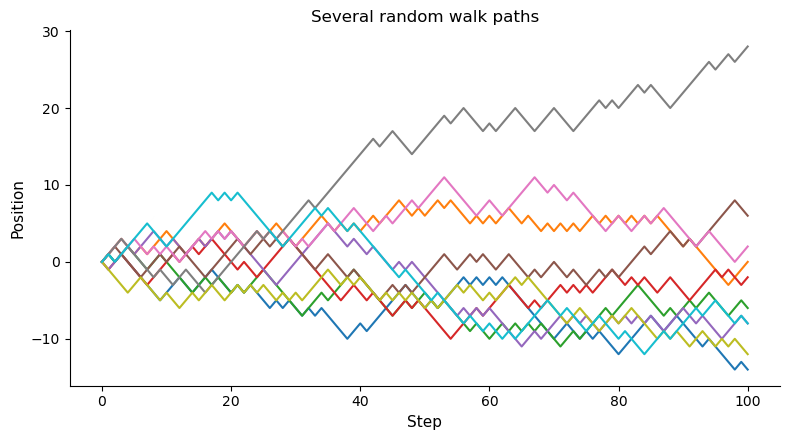

In [28]:
# Number of steps
n_steps = 100

# Probability of moving to the right
p = 0.5

# Number of sample paths
n_paths = 10

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for path in range(n_paths):
    # Simulate the steps for one path
    steps = rng.choice([1, -1], size=n_steps, p=[p, 1 - p])

    # Compute the position after each step
    X = np.cumsum(steps)

    # Add the starting position X_0 = 0
    X = np.concatenate(([0], X))

    # Plot this path
    plt.plot(np.arange(n_steps + 1), X)

plt.xlabel("Step")
plt.ylabel("Position")
plt.title("Several random walk paths")
plt.tight_layout()
plt.show()

### Effect of changing $p$

The parameter $p$ controls the direction of the random walk. If $p=0.5$, the walk is symmetric. If $p>0.5$, positive steps are more likely, and the walk tends to move upward. If $p<0.5$, negative steps are more likely, and the walk tends to move downward. The mean after $n$ steps is

$$
E(X_n) = (2p-1)n.
$$

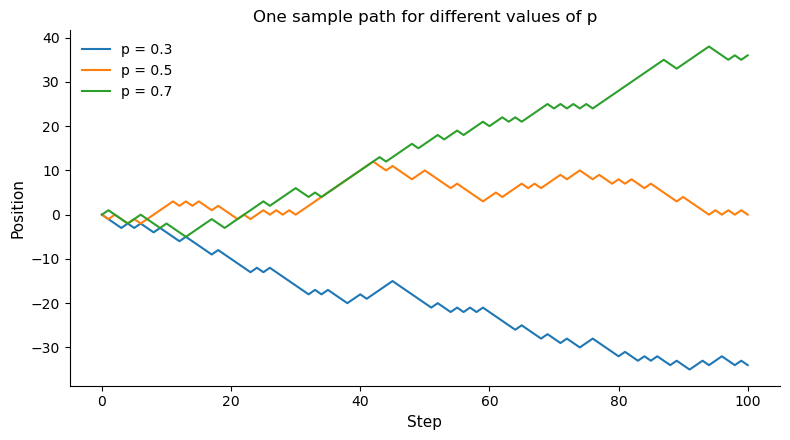

In [29]:
# Number of steps
n_steps = 100

# Different probabilities of moving to the right
p_values = [0.3, 0.5, 0.7]

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for p in p_values:
    # Simulate one path for this value of p
    steps = rng.choice([1, -1], size=n_steps, p=[p, 1 - p])

    # Compute the position after each step
    X = np.cumsum(steps)

    # Add the starting position X_0 = 0
    X = np.concatenate(([0], X))

    # Plot this path
    plt.plot(np.arange(n_steps + 1), X, label=f"p = {p}")

plt.xlabel("Step")
plt.ylabel("Position")
plt.title("One sample path for different values of p")
plt.legend()
plt.tight_layout()
plt.show()

The simulations show the change in drift.

For $p=0.5$, the paths fluctuate around zero. For $p=0.7$, the paths usually move upward. For $p=0.3$, they usually move downward.

The random paths are still variable, but the average direction changes with $p$.

## Example 3: Distribution of the final position

A single path shows one realization. To study the distribution of the random walk, we repeat the same experiment many times. After $n$ steps, the final position is

$$
X_n = Z_1 + Z_2 + \cdots + Z_n.
$$

For the symmetric case $p=0.5$, most final positions are close to $0$, but larger positive or negative values are also possible. Since each step is either $+1$ or $-1$, the final position only takes every second integer value.

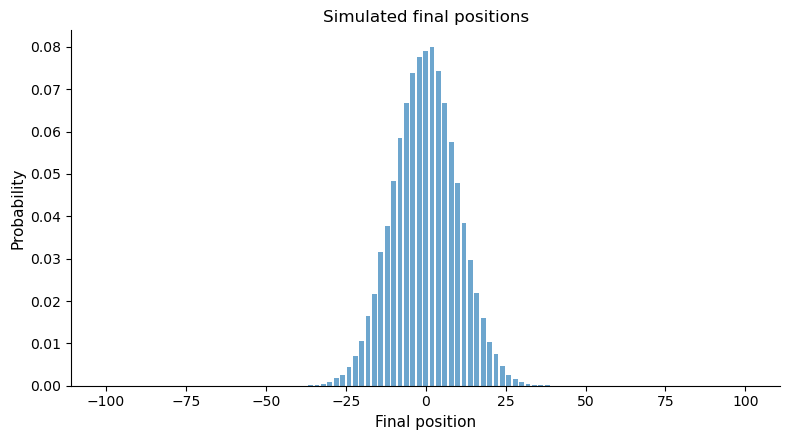

In [30]:
# Number of steps in one random walk
n_steps = 100

# Probability of moving to the right
p = 0.5

# Number of repeated simulations
N = 100000

# Create a random generator
rng = np.random.default_rng()

# Simulate all steps
steps = rng.choice([1, -1], size=(N, n_steps), p=[p, 1 - p])

# Compute the final position of each path
X_final = np.sum(steps, axis=1)

# Possible final positions
x_values = np.arange(-n_steps, n_steps + 1, 2)

# Simulated probability for each final position
simulated_probabilities = []

for x in x_values:
    probability = np.mean(X_final == x)
    simulated_probabilities.append(probability)

# Plot the simulated final position distribution
plt.figure(figsize=FIGSIZE)

plt.bar(x_values, simulated_probabilities, width=1.5, alpha=HIST_ALPHA)

plt.xlabel("Final position")
plt.ylabel("Probability")
plt.title("Simulated final positions")
plt.tight_layout()
plt.show()

The final position $X_n$ depends on the number of right steps. Let $R_n$ be the number of right steps in $n$ steps. Since each step moves right with probability $p$,

$$
R_n \sim \mathrm{Bin}(n,p).
$$

If the walk moves right $R_n$ times, then it moves left $n-R_n$ times. Therefore,

$$
X_n = R_n - (n-R_n) = 2R_n - n.
$$

So the distribution of $X_n$ can be obtained from the binomial distribution of $R_n$. We now compare the simulated probabilities with the exact probabilities.

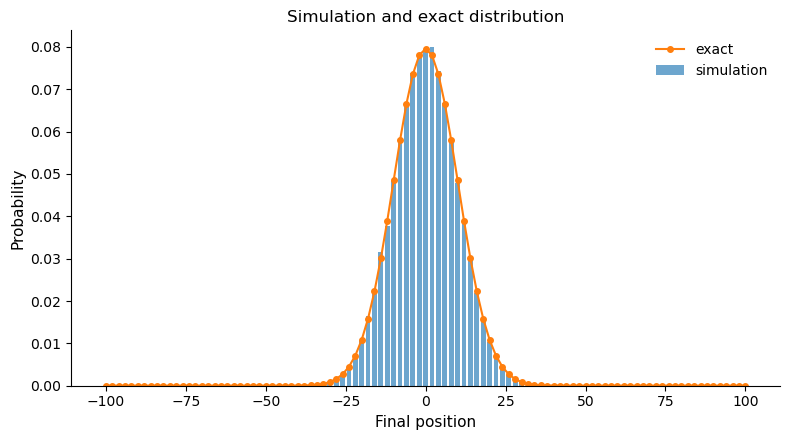

In [31]:
# Possible numbers of right steps
r_values = np.arange(0, n_steps + 1)

# Convert number of right steps to final positions
x_values = 2 * r_values - n_steps

# Exact probabilities from the binomial distribution
p_exact = binom.pmf(r_values, n_steps, p)

# Simulated probability for each final position
simulated_probabilities = []

for x in x_values:
    probability = np.mean(X_final == x)
    simulated_probabilities.append(probability)

# Plot simulated probabilities and exact probabilities
plt.figure(figsize=FIGSIZE)

plt.bar(
    x_values,
    simulated_probabilities,
    width=1.5,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(
    x_values,
    p_exact,
    "o-",
    color="C1",
    label="exact"
)

plt.xlabel("Final position")
plt.ylabel("Probability")
plt.title("Simulation and exact distribution")
plt.legend()
plt.tight_layout()
plt.show()

The simulated endpoint probabilities are close to the exact binomial probabilities. The comparison changes the focus from one path to the distribution of one value, $X_n$. It also shows how repeated simulation can be checked against a result derived from the model.

## Example 4: Gambler's ruin

A gambler starts with initial fortune $i$. At each step, the fortune increases by $1$ with probability $p$, and decreases by $1$ with probability $q=1-p$. Let $X_n$ be the gambler's fortune after $n$ steps. Then

$$
X_{n+1} = X_n + Z_{n+1},
$$

where

$$
Z_{n+1} =
\begin{cases}
1, & \text{with probability } p,\\
-1, & \text{with probability } q.
\end{cases}
$$

The game stops when the fortune reaches either $0$ or $r$:

$$
\tau = \min\{n \ge 0: X_n = 0 \text{ or } X_n = r\}.
$$

Reaching $0$ means ruin, and reaching $r$ means success. The success probability depends on the initial fortune $i$. We denote it by

$$
p_i = \mathbb{P}_i(X_\tau = r),
$$

where the subscript $i$ means that the walk starts from $X_0=i$.

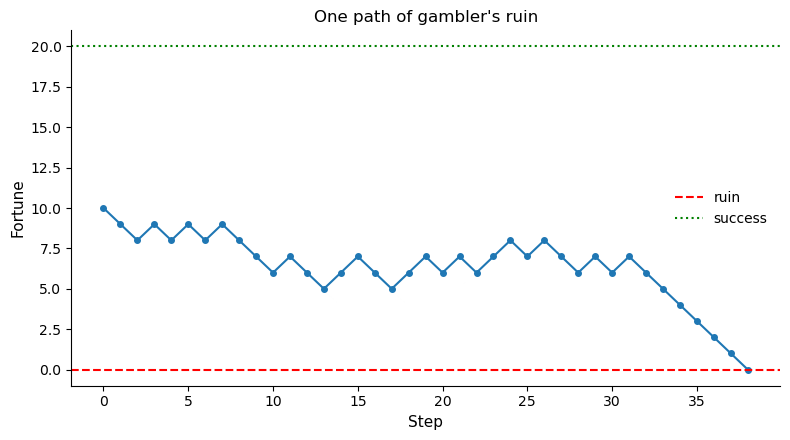

In [32]:
# Initial fortune
i = 10

# Target fortune
r = 20

# Probability of winning one unit
p = 0.5

# Create a random generator
rng = np.random.default_rng()

# Store the fortune path
X = [i]

# Simulate until the fortune hits 0 or r
while 0 < X[-1] < r:
    step = rng.choice([1, -1], p=[p, 1 - p])
    X.append(X[-1] + step)

# Plot the path
plt.figure(figsize=FIGSIZE)

plt.plot(np.arange(len(X)), X, marker="o")
plt.axhline(0, linestyle="--", color="red", label="ruin")
plt.axhline(r, linestyle=":", color="green", label="success")

plt.xlabel("Step")
plt.ylabel("Fortune")
plt.title("One path of gambler's ruin")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
print("Stopping time:", len(X) - 1)
print("Final fortune:", X[-1])

if X[-1] == r:
    print("Result: success")
else:
    print("Result: ruin")

Stopping time: 38
Final fortune: 0
Result: ruin


### Several sample paths

One path shows one possible outcome. If we repeat the game several times, some paths reach $0$ first, while others reach $r$ first. The stopping time is also random. Some games end quickly, while others continue for a longer time.

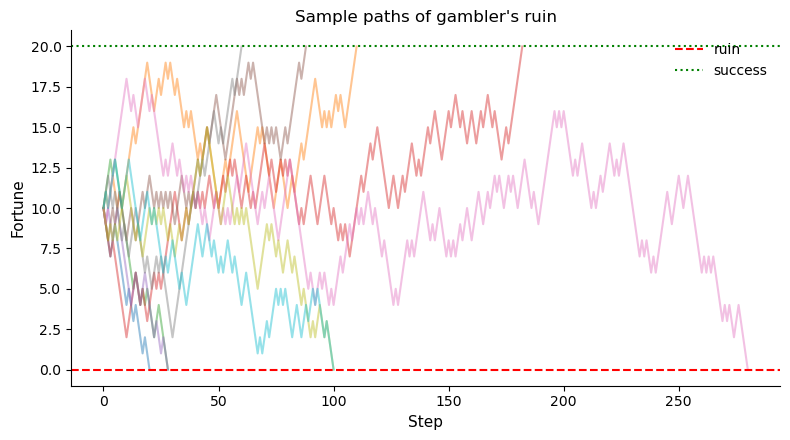

In [34]:
# Initial fortune
i = 10

# Target fortune
r = 20

# Probability of winning one unit
p = 0.5

# Number of sample paths
n_paths = 10

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for path in range(n_paths):
    # Store one fortune path
    X = [i]

    # Simulate until the fortune hits 0 or r
    while 0 < X[-1] < r:
        step = rng.choice([1, -1], p=[p, 1 - p])
        X.append(X[-1] + step)

    # Plot this path
    plt.plot(np.arange(len(X)), X, alpha=OVERLAP_ALPHA)

plt.axhline(0, linestyle="--", color="red", label="ruin")
plt.axhline(r, linestyle=":", color="green", label="success")

plt.xlabel("Step")
plt.ylabel("Fortune")
plt.title("Sample paths of gambler's ruin")
plt.legend()
plt.tight_layout()
plt.show()

### Estimate the success probability

Now we repeat the game many times. For each run, we record whether the path reaches $r$ before it reaches $0$. Since the success probability depends on the initial fortune $i$, we estimate

$$
p_i = \mathbb{P}_i(X_\tau = r).
$$

The Monte Carlo estimate is

$$
\hat p_i =
\frac{1}{N}
\sum_{m=1}^{N}
1\{X^{(m)}_{\tau_m}=r\}.
$$

This is the number of successful runs divided by the total number of runs.

In [35]:
# Initial fortune
i = 10

# Target fortune
r = 20

# Probability of winning one unit
p = 0.5

# Number of repeated simulations
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Count successful runs
success_count = 0

for run in range(N):
    # Start one game
    fortune = i

    # Simulate until ruin or success
    while 0 < fortune < r:
        step = rng.choice([1, -1], p=[p, 1 - p])
        fortune = fortune + step

    # Check whether this run is successful
    if fortune == r:
        success_count = success_count + 1

# Monte Carlo estimate of p_i
p_i_hat = success_count / N

print("Estimated success probability:", p_i_hat)

Estimated success probability: 0.4939


In [36]:
# Exact success probability
q = 1 - p

if np.isclose(p, 0.5):
    p_i_exact = i / r
else:
    p_i_exact = (1 - (q / p) ** i) / (1 - (q / p) ** r)

print("Estimated success probability:", p_i_hat)
print("Exact success probability:", p_i_exact)

Estimated success probability: 0.4939
Exact success probability: 0.5


For the symmetric case $p=0.5$, the exact success probability is

$$
p_i = \frac{i}{r}.
$$

For $p \ne 0.5$, the exact formula is

$$
p_i =
\frac{1-(q/p)^i}{1-(q/p)^r}.
$$

The Monte Carlo estimate should be close to the exact value when the number of repeated simulations is large.

This example uses the same random walk rule for a different question. The endpoint experiment fixes the time and records a random position. Gambler's ruin fixes the two boundaries and records which boundary is reached first. Comparing the simulated success probability with the exact formula shows how stopped paths can be used to estimate a boundary event.